In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


In [ ]:
# 1. Load the datas
df = pd.read_csv('/content/ecommerce_customers - ecommerce_customers.csv')

In [ ]:
print(df.head())
print(df.info())
print(df.describe())

   CustomerID  Time_Spent_Minutes  Pages_Visited  Cart_Adds  Purchases  \
0           1                   5              3          0          0   
1           2                  20              8          2          1   
2           3                  35             12          5          3   
3           4                  10              4          1          0   
4           5                  60             25         10          6   

   Revenue   Device  
0        0   Mobile  
1       50  Desktop  
2      180  Desktop  
3        0   Mobile  
4      500  Desktop  
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10 entries, 0 to 9
Data columns (total 7 columns):
 #   Column              Non-Null Count  Dtype 
---  ------              --------------  ----- 
 0   CustomerID          10 non-null     int64 
 1   Time_Spent_Minutes  10 non-null     int64 
 2   Pages_Visited       10 non-null     int64 
 3   Cart_Adds           10 non-null     int64 
 4   Purchases           10 non-nu

In [ ]:
print("Missing values per column:")
print(df.isnull().sum())

Missing values per column:
CustomerID            0
Time_Spent_Minutes    0
Pages_Visited         0
Cart_Adds             0
Purchases             0
Revenue               0
Device                0
dtype: int64


In [ ]:
print(f"Number of duplicate rows: {df.duplicated().sum()}")

Number of duplicate rows: 0


In [ ]:
df = df.drop_duplicates()

In [ ]:
df = df.dropna()

In [ ]:
# 2.conditions for segmentation
conditions = [
    (df['Purchases'] > 300),
    (df['Purchases'] > 3),
    (df['Time_Spent_Minutes'] > 30)
]

In [ ]:
print(df.head())

   CustomerID  Time_Spent_Minutes  Pages_Visited  Cart_Adds  Purchases  \
0           1                   5              3          0          0   
1           2                  20              8          2          1   
2           3                  35             12          5          3   
3           4                  10              4          1          0   
4           5                  60             25         10          6   

   Revenue   Device  
0        0   Mobile  
1       50  Desktop  
2      180  Desktop  
3        0   Mobile  
4      500  Desktop  


In [ ]:
features = df[['Time_Spent_Minutes', 'Purchases']]

In [ ]:
# 3. Define corresponding labels
choices = ['High Value Buyer', 'Active Buyer', 'Browsers']

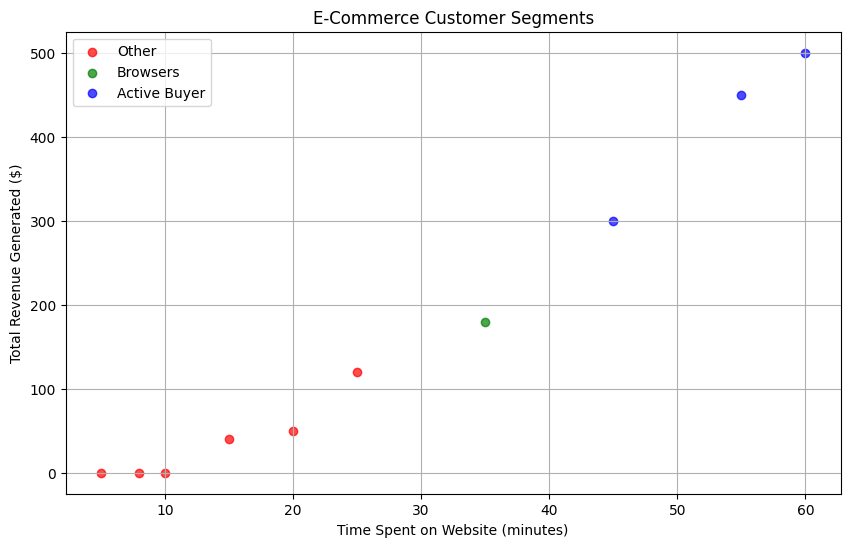

In [ ]:



df['Segment'] = np.select(conditions, choices, default='Other')

colors = {
    "High Value Buyer": "yellow",
    "Active Buyer": "blue",
    "Browsers": "green",
    "Other": "red"
}

plt.figure(figsize=(10, 6))

for segment in df['Segment'].unique():
    subset = df[df['Segment'] == segment]
    plt.scatter(
        subset['Time_Spent_Minutes'],
        subset['Revenue'],
        label=segment,
        color=colors[segment],
        alpha=0.7
    )

plt.xlabel("Time Spent on Website (minutes)")
plt.ylabel("Total Revenue Generated ($)")
plt.title("E-Commerce Customer Segments")
plt.legend()
plt.grid(True)
plt.show()

In [ ]:
# Save the resulting DataFrame to a new CSV file

df.to_csv('segmented_customers.csv', index=False)

print("File 'segmented_customers.csv' has been saved successfully.")

File 'segmented_customers.csv' has been saved successfully.
